# Lab 3: Hindi Sentence Tokenization, BPE and WordPiece

1. Sentence-tokenize IndicCorp v2 Hindi paragraphs -> sentences
2. Length-balanced Train / Dev(1000) / Test(1000) split
3. From-scratch BPE and WordPiece implementations
4. Effect of training-data size (100k / 300k / 500k / 1M) on tokenization of dev+test
5. Effect of vocabulary size (20k / 30k / 50k) on tokenization of dev+test


In [1]:
import os, re, random, urllib.request
from collections import Counter, defaultdict
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)

DATA_URL         = 'https://huggingface.co/datasets/ai4bharat/IndicCorpV2/resolve/main/data/hi-1.txt'
CORPUS_FILE      = 'hindi_1_1m_sentences.txt'
TARGET_SENTENCES = 1_100_000


In [2]:
# Cell 2: Sentence tokenizer + corpus download

def sentence_tokenize(text):
    """Split a Hindi paragraph into sentences on ।/॥/./?/! boundaries."""
    if not text or not text.strip():
        return []
    text = re.sub(r'\s+', ' ', text.strip())
    chunks = re.split(r'(?<=[\u0964\u0965.!?])\s+', text)
    return [c.strip() for c in chunks
            if len(c.strip()) >= 3 and not re.fullmatch(r'[\s\W_]+', c)]


def download_hindi_corpus(url=DATA_URL, out_path=CORPUS_FILE, target=TARGET_SENTENCES):
    if os.path.exists(out_path):
        count = sum(1 for _ in open(out_path, encoding='utf-8'))
        print(f'{out_path} already exists ({count} sentences).')
        return
    print(f'Downloading and tokenizing (target {target} sentences)...')
    n = 0
    with urllib.request.urlopen(urllib.request.Request(url)) as resp, \
         open(out_path, 'w', encoding='utf-8') as fout:
        for raw in resp:
            for sent in sentence_tokenize(raw.decode('utf-8', 'ignore')):
                fout.write(sent + '\n')
                n += 1
                if n >= target: break
            if n >= target: break
    print(f'Done -- {n} sentences written to {out_path}')


download_hindi_corpus()


hindi_1_1m_sentences.txt already exists (1100000 sentences).


In [3]:
# Cell 3: Load corpus + length-balanced Train/Dev/Test split

with open(CORPUS_FILE, encoding='utf-8') as f:
    all_sentences = [l.strip() for l in f if l.strip()]
print(f'Total sentences: {len(all_sentences)}')


def length_balanced_split(sentences, dev_size=1000, test_size=1000, seed=SEED):
    """
    Sort by word-count, divide into 10 deciles, draw dev_size//10 and
    test_size//10 sentences from each decile to guarantee length diversity.
    """
    rng = random.Random(seed)
    sorted_sents = sorted(sentences, key=lambda s: len(s.split()))
    total    = len(sorted_sents)
    decile   = total // 10
    dev_per  = dev_size  // 10
    test_per = test_size // 10
    dev_set, test_set, train_set = [], [], []
    for d in range(10):
        sl = sorted_sents[d*decile : (d+1)*decile if d < 9 else total]
        rng.shuffle(sl)
        dev_set.extend(sl[:dev_per])
        test_set.extend(sl[dev_per : dev_per + test_per])
        train_set.extend(sl[dev_per + test_per:])
    return train_set, dev_set, test_set


train_sentences, dev_sentences, test_sentences = length_balanced_split(all_sentences)
print(f'Train: {len(train_sentences)} | Dev: {len(dev_sentences)} | Test: {len(test_sentences)}')
avg = lambda lst: sum(len(s.split()) for s in lst) / len(lst)
print(f'Avg words -- Train: {avg(train_sentences):.2f} | Dev: {avg(dev_sentences):.2f} | Test: {avg(test_sentences):.2f}')

with open('hindi_train.txt', 'w', encoding='utf-8') as f: f.write('\n'.join(train_sentences))
with open('hindi_dev.txt',   'w', encoding='utf-8') as f: f.write('\n'.join(dev_sentences))
with open('hindi_test.txt',  'w', encoding='utf-8') as f: f.write('\n'.join(test_sentences))


Total sentences: 1100000
Train: 1098000 | Dev: 1000 | Test: 1000
Avg words -- Train: 17.66 | Dev: 17.65 | Test: 17.51


In [6]:
# Cell 4: BPE and WordPiece from scratch

# -- BPE --
def train_bpe(sentences, vocab_size=20000):
    word_counts = Counter()
    for s in sentences:
        for tok in s.split():
            word_counts[tuple(tok)] += 1

    vocab = set(c for word in word_counts for c in word)
    merges = {}
    pair_counts  = Counter()
    pair_to_words = defaultdict(set)
    for word, cnt in word_counts.items():
        for i in range(len(word) - 1):
            p = (word[i], word[i+1])
            pair_counts[p] += cnt
            pair_to_words[p].add(word)

    while len(vocab) < vocab_size and pair_counts:
        best = max(pair_counts, key=pair_counts.get)
        if pair_counts[best] <= 0: break
        merged = best[0] + best[1]
        vocab.add(merged)
        merges[best] = merged
        affected = list(pair_to_words[best])
        del pair_counts[best]; del pair_to_words[best]
        for word in affected:
            cnt = word_counts[word]
            new_word, i = [], 0
            while i < len(word):
                if i < len(word)-1 and (word[i], word[i+1]) == best:
                    new_word.append(merged); i += 2
                else:
                    new_word.append(word[i]); i += 1
            new_word = tuple(new_word)
            for j in range(len(word)-1):
                op = (word[j], word[j+1])
                pair_counts[op] -= cnt
                pair_to_words[op].discard(word)
                if pair_counts[op] <= 0: del pair_counts[op]
            word_counts[new_word] = word_counts.get(new_word, 0) + cnt
            if word != new_word: del word_counts[word]
            for j in range(len(new_word)-1):
                np_ = (new_word[j], new_word[j+1])
                pair_counts[np_] += cnt
                pair_to_words[np_].add(new_word)

    merge_ranks = {pair: i for i, pair in enumerate(merges)}
    return vocab, merges, merge_ranks


def bpe_encode(word, merges, merge_ranks):
    if len(word) <= 1: return list(word)
    symbols = list(word)
    while True:
        pairs = [(symbols[i], symbols[i+1]) for i in range(len(symbols)-1)]
        if not pairs: break
        best  = min(pairs, key=lambda p: merge_ranks.get(p, float('inf')))
        if best not in merge_ranks: break
        new_s, i = [], 0
        while i < len(symbols):
            if i < len(symbols)-1 and (symbols[i], symbols[i+1]) == best:
                new_s.append(merges[best]); i += 2
            else:
                new_s.append(symbols[i]); i += 1
        symbols = new_s
    return symbols


# -- WordPiece --
def train_wordpiece(sentences, vocab_size=20000):
    """Incremental WordPiece: merges pair maximising count(A,B)/(count(A)*count(B))."""
    word_counts = Counter()
    for s in sentences:
        for tok in s.split():
            chars = [tok[0]] + ['##' + c for c in tok[1:]]
            word_counts[tuple(chars)] += 1

    vocab = set()
    token_counts = Counter()
    for word, cnt in word_counts.items():
        for t in word: vocab.add(t); token_counts[t] += cnt

    merges = {}
    pair_counts   = Counter()
    pair_to_words = defaultdict(set)
    for word, cnt in word_counts.items():
        for i in range(len(word)-1):
            p = (word[i], word[i+1])
            pair_counts[p] += cnt; pair_to_words[p].add(word)

    while len(vocab) < vocab_size and pair_counts:
        best = None; best_score = -1
        for pair, cnt in pair_counts.items():
            if cnt < 5: continue
            a, b  = pair
            score = cnt / (token_counts[a] * token_counts[b])
            if score > best_score: best_score = score; best = pair
        if best is None: best = max(pair_counts, key=pair_counts.get)

        a, b   = best
        merged = a + b[2:] if b.startswith('##') else a + b
        vocab.add(merged); merges[best] = merged
        affected = list(pair_to_words[best])
        del pair_counts[best]; del pair_to_words[best]

        for word in affected:
            cnt = word_counts[word]
            for t in word: token_counts[t] -= cnt
            for j in range(len(word)-1):
                op = (word[j], word[j+1])
                pair_counts[op] -= cnt; pair_to_words[op].discard(word)
                if pair_counts[op] <= 0: del pair_counts[op]
            new_word, i = [], 0
            while i < len(word):
                if i < len(word)-1 and (word[i], word[i+1]) == best:
                    new_word.append(merged); i += 2
                else:
                    new_word.append(word[i]); i += 1
            new_word = tuple(new_word)
            word_counts[new_word] = word_counts.get(new_word, 0) + cnt
            if word != new_word: del word_counts[word]
            for t in new_word: token_counts[t] += cnt
            for j in range(len(new_word)-1):
                np_ = (new_word[j], new_word[j+1])
                pair_counts[np_] += cnt; pair_to_words[np_].add(new_word)

    return vocab, merges


def wordpiece_encode(word, vocab):
    if word in vocab: return [word]
    tokens, start = [], 0
    while start < len(word):
        end, cur = len(word), None
        while start < end:
            sub = ('##' if start > 0 else '') + word[start:end]
            if sub in vocab: cur = sub; break
            end -= 1
        if cur is None: return ['[UNK]']
        tokens.append(cur); start = end
    return tokens


print('Algorithms ready.')


Algorithms ready.



-- Training size: 100,000 sentences --
  Dev  -- BPE: 1.165 tok/word | WP: 1.842 tok/word | WP OOV: 0.00%
  Test -- BPE: 1.172 tok/word | WP: 1.845 tok/word | WP OOV: 0.01%

-- Training size: 300,000 sentences --
  Dev  -- BPE: 1.141 tok/word | WP: 2.830 tok/word | WP OOV: 0.00%
  Test -- BPE: 1.153 tok/word | WP: 2.839 tok/word | WP OOV: 0.01%

-- Training size: 500,000 sentences --
  Dev  -- BPE: 1.135 tok/word | WP: 3.197 tok/word | WP OOV: 0.00%
  Test -- BPE: 1.148 tok/word | WP: 3.202 tok/word | WP OOV: 0.01%

-- Training size: 1,000,000 sentences --
  Dev  -- BPE: 1.133 tok/word | WP: 3.934 tok/word | WP OOV: 0.00%
  Test -- BPE: 1.147 tok/word | WP: 3.942 tok/word | WP OOV: 0.00%

Summary (vocab = 20 000):
  train_size |  BPE dev |  BPE test |  WP dev |  WP test
--------------------------------------------------------
     100,000 |    1.165 |     1.172 |   1.842 |    1.845
     300,000 |    1.141 |     1.153 |   2.830 |    2.839
     500,000 |    1.135 |     1.148 |   3.197 |

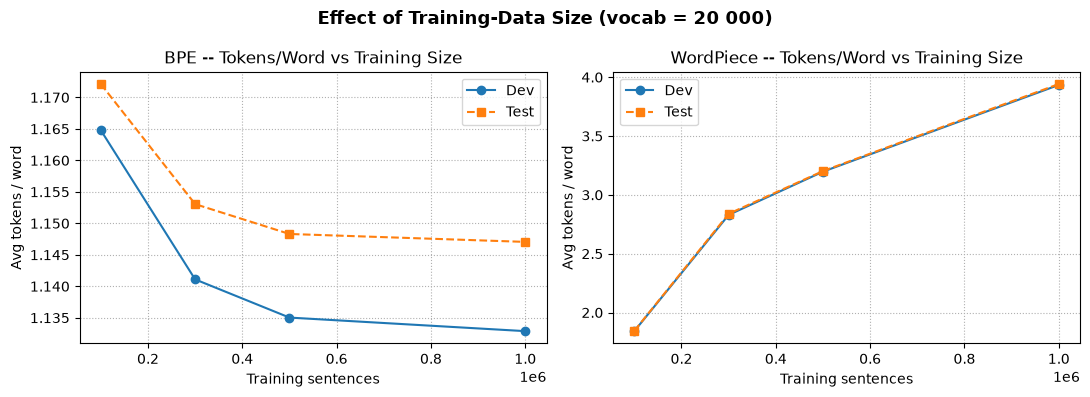

In [7]:
# Cell 5: Effect of training-data size (vocab fixed at 20 000)

def eval_on_corpus(sentences, bpe_m, bpe_r, wp_v):
    """Return avg BPE tok/word, avg WP tok/word, WP OOV word-rate."""
    bpe_t = wp_t = words = unk = 0
    for sent in sentences:
        ws = sent.split()
        words += len(ws)
        for w in ws:
            bt = bpe_encode(w, bpe_m, bpe_r)
            wt = wordpiece_encode(w, wp_v)
            bpe_t += len(bt)
            wp_t  += len(wt)
            if '[UNK]' in wt: unk += 1
    return bpe_t/words, wp_t/words, unk/words


TRAIN_SIZES  = [100_000, 300_000, 500_000, 1_000_000]
FIXED_VOCAB  = 20_000
size_results = []

for size in TRAIN_SIZES:
    print(f'\n-- Training size: {size:,} sentences --')
    subset = train_sentences[:size]
    bpe_v, bpe_m, bpe_r = train_bpe(subset, vocab_size=FIXED_VOCAB)
    wp_v,  wp_m         = train_wordpiece(subset, vocab_size=FIXED_VOCAB)

    dev_bpe,  dev_wp,  dev_unk  = eval_on_corpus(dev_sentences,  bpe_m, bpe_r, wp_v)
    test_bpe, test_wp, test_unk = eval_on_corpus(test_sentences, bpe_m, bpe_r, wp_v)

    print(f'  Dev  -- BPE: {dev_bpe:.3f} tok/word | WP: {dev_wp:.3f} tok/word | WP OOV: {dev_unk:.2%}')
    print(f'  Test -- BPE: {test_bpe:.3f} tok/word | WP: {test_wp:.3f} tok/word | WP OOV: {test_unk:.2%}')
    size_results.append(dict(size=size, dev_bpe=dev_bpe, dev_wp=dev_wp,
                             test_bpe=test_bpe, test_wp=test_wp))

print('\nSummary (vocab = 20 000):')
hdr = f"{'train_size':>12} | {'BPE dev':>8} | {'BPE test':>9} | {'WP dev':>7} | {'WP test':>8}"
print(hdr)
print('-' * len(hdr))
for r in size_results:
    print(f"{r['size']:>12,} | {r['dev_bpe']:>8.3f} | {r['test_bpe']:>9.3f} "
          f"| {r['dev_wp']:>7.3f} | {r['test_wp']:>8.3f}")

sizes = [r['size'] for r in size_results]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(sizes, [r['dev_bpe']  for r in size_results], 'o-',  label='Dev')
ax1.plot(sizes, [r['test_bpe'] for r in size_results], 's--', label='Test')
ax1.set_title('BPE -- Tokens/Word vs Training Size')
ax1.set_xlabel('Training sentences'); ax1.set_ylabel('Avg tokens / word')
ax1.legend(); ax1.grid(True, ls=':')
ax2.plot(sizes, [r['dev_wp']  for r in size_results], 'o-',  label='Dev')
ax2.plot(sizes, [r['test_wp'] for r in size_results], 's--', label='Test')
ax2.set_title('WordPiece -- Tokens/Word vs Training Size')
ax2.set_xlabel('Training sentences'); ax2.set_ylabel('Avg tokens / word')
ax2.legend(); ax2.grid(True, ls=':')
plt.suptitle('Effect of Training-Data Size (vocab = 20 000)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_size_experiment.png', dpi=120)
plt.show()



-- Vocabulary size: 20,000 --
  Dev  -- BPE: 1.135 tok/word | WP: 3.197 tok/word | WP OOV: 0.00%
  Test -- BPE: 1.148 tok/word | WP: 3.202 tok/word | WP OOV: 0.01%

-- Vocabulary size: 30,000 --
  Dev  -- BPE: 1.101 tok/word | WP: 2.884 tok/word | WP OOV: 0.00%
  Test -- BPE: 1.112 tok/word | WP: 2.888 tok/word | WP OOV: 0.01%

-- Vocabulary size: 50,000 --
  Dev  -- BPE: 1.071 tok/word | WP: 2.302 tok/word | WP OOV: 0.00%
  Test -- BPE: 1.079 tok/word | WP: 2.306 tok/word | WP OOV: 0.01%

Summary (train = 500 000):
  vocab_size |  BPE dev |  BPE test |  WP dev |  WP test
--------------------------------------------------------
      20,000 |    1.135 |     1.148 |   3.197 |    3.202
      30,000 |    1.101 |     1.112 |   2.884 |    2.888
      50,000 |    1.071 |     1.079 |   2.302 |    2.306


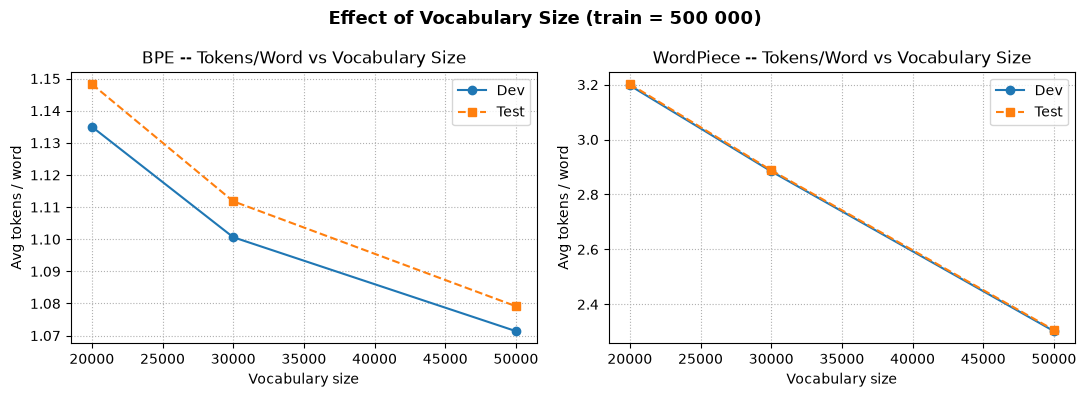

In [8]:
# Cell 6: Effect of vocabulary size (training size fixed at 500 000)

VOCAB_SIZES   = [20_000, 30_000, 50_000]
FIXED_TRAIN   = 500_000
train_corpus  = train_sentences[:FIXED_TRAIN]
vocab_results = []

for v_size in VOCAB_SIZES:
    print(f'\n-- Vocabulary size: {v_size:,} --')
    bpe_v, bpe_m, bpe_r = train_bpe(train_corpus, vocab_size=v_size)
    wp_v,  wp_m         = train_wordpiece(train_corpus, vocab_size=v_size)

    dev_bpe,  dev_wp,  dev_unk  = eval_on_corpus(dev_sentences,  bpe_m, bpe_r, wp_v)
    test_bpe, test_wp, test_unk = eval_on_corpus(test_sentences, bpe_m, bpe_r, wp_v)

    print(f'  Dev  -- BPE: {dev_bpe:.3f} tok/word | WP: {dev_wp:.3f} tok/word | WP OOV: {dev_unk:.2%}')
    print(f'  Test -- BPE: {test_bpe:.3f} tok/word | WP: {test_wp:.3f} tok/word | WP OOV: {test_unk:.2%}')
    vocab_results.append(dict(vocab=v_size, dev_bpe=dev_bpe, dev_wp=dev_wp,
                              test_bpe=test_bpe, test_wp=test_wp))

print('\nSummary (train = 500 000):')
hdr = f"{'vocab_size':>12} | {'BPE dev':>8} | {'BPE test':>9} | {'WP dev':>7} | {'WP test':>8}"
print(hdr)
print('-' * len(hdr))
for r in vocab_results:
    print(f"{r['vocab']:>12,} | {r['dev_bpe']:>8.3f} | {r['test_bpe']:>9.3f} "
          f"| {r['dev_wp']:>7.3f} | {r['test_wp']:>8.3f}")

vocabs = [r['vocab'] for r in vocab_results]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(vocabs, [r['dev_bpe']  for r in vocab_results], 'o-',  label='Dev')
ax1.plot(vocabs, [r['test_bpe'] for r in vocab_results], 's--', label='Test')
ax1.set_title('BPE -- Tokens/Word vs Vocabulary Size')
ax1.set_xlabel('Vocabulary size'); ax1.set_ylabel('Avg tokens / word')
ax1.legend(); ax1.grid(True, ls=':')
ax2.plot(vocabs, [r['dev_wp']  for r in vocab_results], 'o-',  label='Dev')
ax2.plot(vocabs, [r['test_wp'] for r in vocab_results], 's--', label='Test')
ax2.set_title('WordPiece -- Tokens/Word vs Vocabulary Size')
ax2.set_xlabel('Vocabulary size'); ax2.set_ylabel('Avg tokens / word')
ax2.legend(); ax2.grid(True, ls=':')
plt.suptitle('Effect of Vocabulary Size (train = 500 000)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('vocab_size_experiment.png', dpi=120)
plt.show()
